# March Madness Prediction Workflow

This notebook orchestrates the entire March Madness prediction pipeline, from data loading to bracket visualization. We'll use the modular class architecture to:

1. Load and preprocess tournament data
2. Calculate ELO ratings for all teams
3. Calculate advanced team statistics
4. Train a machine learning model
5. Generate tournament predictions
6. Visualize the completed bracket
7. Create a submission file

Let's get started!

## 1. Import Required Libraries and Classes

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set a nice plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Import our custom classes
from data_classes.processing import MarchMadnessDataManager, EloRatingSystem, MarchMadnessPredictor, MarchMadnessMLModel, TeamStatsCalculator
from data_classes.bracket import BracketSimulator

## 2. Configure Settings

In [3]:
# Configuration
CURRENT_SEASON = 2025  # Current/target season
DATA_DIR = f"../data/{CURRENT_SEASON}"  # Directory containing March Madness data files
GENDER = "M"        # M for men's tournament, W for women's
ELO_START_YEAR = 2003  # First year to use for ELO rating calculation
ML_START_YEAR = 2003   # First year to use for ML model training
SUBMISSION_FILE = f"submission_2025_{GENDER}.csv"  # Path to save the submission file
GET_ALL_MATCHUPS = True # Set to true pre-bracket release

# Ensure required directories exist
os.makedirs("output", exist_ok=True)

## 3. Load and Preprocess Data

We'll use the `MarchMadnessDataManager` to load and preprocess our data files.

In [4]:
# Initialize the data manager
data_manager = MarchMadnessDataManager(DATA_DIR, GENDER, CURRENT_SEASON)

# Load all data files
data = data_manager.load_data()

# Display summary of loaded data
print("Loaded data files:")
for key, df in data.items():
    print(f"  - {key}: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 10 datasets
Loaded data files:
  - teams: 364 rows, 4 columns
  - regular_season: 191796 rows, 8 columns
  - tourney_results: 2518 rows, 8 columns
  - tourney_seeds: 2558 rows, 3 columns
  - tourney_slots: 2519 rows, 4 columns
  - regular_season_detailed: 117748 rows, 34 columns
  - tourney_detailed: 1382 rows, 34 columns
  - rankings: 5489117 rows, 5 columns
  - secondary_tourney: 1809 rows, 9 columns
  - processed_seeds: 2558 rows, 5 columns


## 4. Calculate ELO Ratings

We'll use the `EloRatingSystem` to calculate ELO ratings for all teams from historical game results.

In [ ]:
# Initialize ELO rating system
elo_system = EloRatingSystem(data_manager)

# Calculate ELO ratings
elo_ratings = elo_system.calculate_elo_ratings(
    start_year=ELO_START_YEAR,
    k_factor=30,            # How much each game impacts ratings
    home_advantage=100,     # Home court advantage in ELO points
    carry_over_factor=0.75  # How much rating carries over between seasons
)

# Get current ELO ratings for the tournament teams
current_elo = elo_system.get_all_teams_elo(CURRENT_SEASON)

# Display top 10 teams by ELO rating
print("Top 10 teams by ELO rating:")
display(current_elo.head(10))

# Visualize ELO distribution
plt.figure(figsize=(10, 6))
sns.histplot(current_elo['ELO'], bins=20, kde=True)
plt.title(f"Distribution of Team ELO Ratings ({CURRENT_SEASON})")
plt.xlabel("ELO Rating")
plt.ylabel("Count")
plt.show()

## 5. Calculate Advanced Team Statistics

Now we'll use the `TeamStatsCalculator` to calculate advanced metrics for all teams.

In [ ]:
# Initialize the team stats calculator
stats_calculator = TeamStatsCalculator(data_manager)

try:
    # Calculate advanced team statistics
    advanced_stats = stats_calculator.calculate_advanced_team_stats(start_season=ELO_START_YEAR)
    
    # Get current season stats for tournament teams
    current_stats = {}
    
    if CURRENT_SEASON in advanced_stats:
        # Create a DataFrame of key metrics for the current season's teams
        teams = data_manager.data['teams']['TeamID'].unique()
        tournament_teams = data_manager.get_tournament_teams(CURRENT_SEASON, get_all_matchups=GET_ALL_MATCHUPS)['TeamID'].values
        # Get team stats
        team_data = []
        for team_id in tournament_teams:
            if team_id in advanced_stats[CURRENT_SEASON]:
                team_stats = advanced_stats[CURRENT_SEASON][team_id]
                team_name = data_manager.get_team_name(team_id)
                
                team_data.append({
                    'TeamID': team_id,
                    'TeamName': team_name,
                    'OffEff': team_stats.get('OffEff', 0),
                    'DefEff': team_stats.get('DefEff', 0),
                    'NetEff': team_stats.get('NetEff', 0),
                    'Pace': team_stats.get('Pace', 0),
                    'eFG%': team_stats.get('eFG%', 0),
                    'TOV%': team_stats.get('TOV%', 0),
                    'ORB%': team_stats.get('ORB%', 0),
                    'FTRate': team_stats.get('FTRate', 0)
                })
        print(len(team_data))
        
        current_stats = pd.DataFrame(team_data)
        current_stats = current_stats.sort_values('NetEff', ascending=False)
        
        # Display top 10 teams by net efficiency
        print("\nTop 10 teams by Net Efficiency:")
        display(current_stats.head(10))
        
        # Create a visualization of offensive vs defensive efficiency
        plt.figure(figsize=(12, 10))
        sns.scatterplot(x='DefEff', y='OffEff', size='NetEff', hue='Pace',
                       data=current_stats, sizes=(50, 400), alpha=0.7)
        
        # Add team labels
        for _, row in current_stats.head(15).iterrows():
            plt.text(row['DefEff']+0.5, row['OffEff']+0.5, row['TeamName'], 
                    fontsize=9, alpha=0.8)
        
        plt.title(f"{CURRENT_SEASON} Team Efficiency Landscape", fontsize=16)
        plt.xlabel("Defensive Efficiency (lower is better)", fontsize=12)
        plt.ylabel("Offensive Efficiency (higher is better)", fontsize=12)
        plt.xlim(85, 110)
        plt.ylim(95, 125)
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print(f"Warning: No advanced stats available for {CURRENT_SEASON}")
        
except Exception as e:
    print(f"Error calculating advanced stats: {e}")
    # Create empty stats to continue the workflow
    advanced_stats = {}
    current_stats = pd.DataFrame()

## 6. Train Machine Learning Model

Now we'll train a machine learning model to predict tournament game outcomes.

Loaded 10 datasets
Creating features from 2003 to current season...
First pass: identifying all possible features...
Identified 31 unique features
Second pass: creating consistent feature vectors...
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing data
missing 

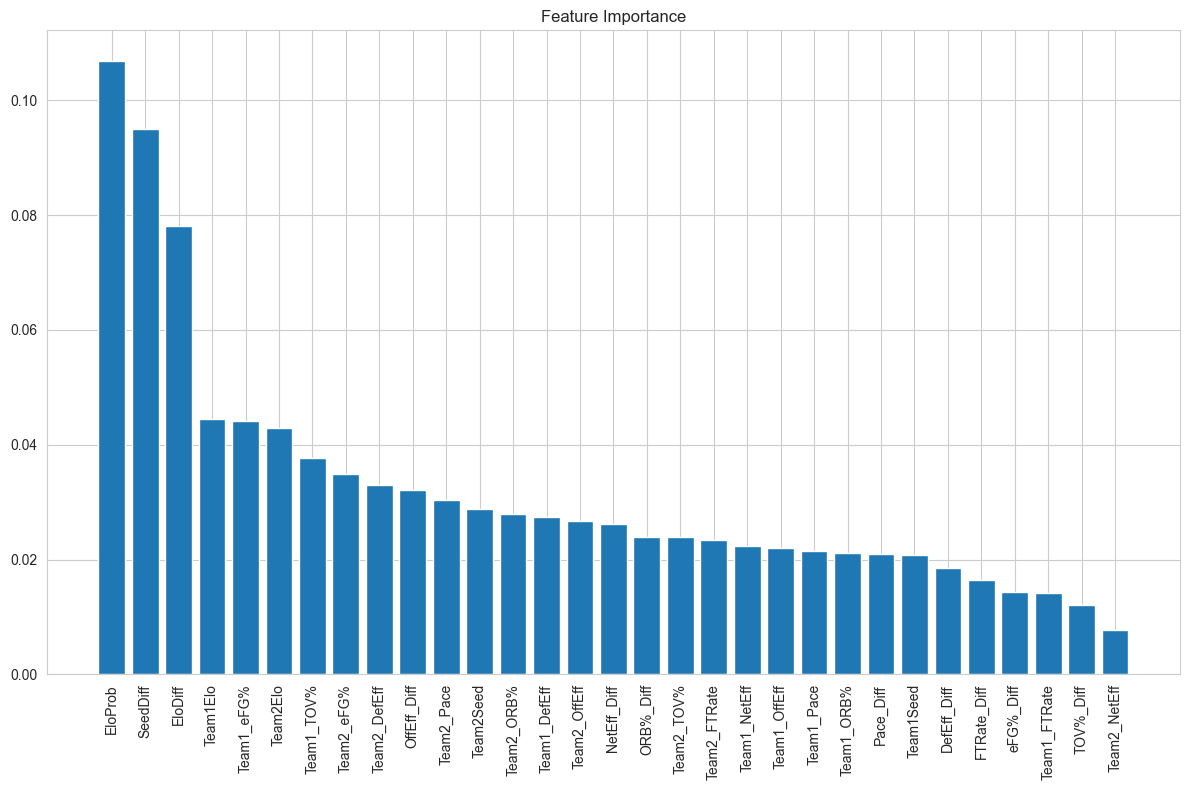

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Initialize ML model
ml_model = MarchMadnessMLModel(data_manager, elo_system, stats_calculator)
ml_model.train_model(model_type='randomforest')

## 7. Initialize the Main Predictor

Now let's bring it all together with the main `MarchMadnessPredictor` class.

Calculating ELO ratings from 2003 to 2025...
Calculated ELO ratings for 23 seasons
Calculating advanced team stats from 2003 to 2025...
Calculated advanced stats for 23 seasons
Creating feature dataset...
Creating feature dataset...
Calculating advanced team stats from 2003 to 2025...
Calculated advanced stats for 23 seasons
Created feature dataset with 1868 samples
Training set: 1494 samples
Test set: 374 samples
Model Training Results:
Training Accuracy: 0.9712, Test Accuracy: 0.9358
Training Log Loss: 0.2039, Test Log Loss: 0.2411
Training Brier Score: 0.0544, Test Brier Score: 0.0689


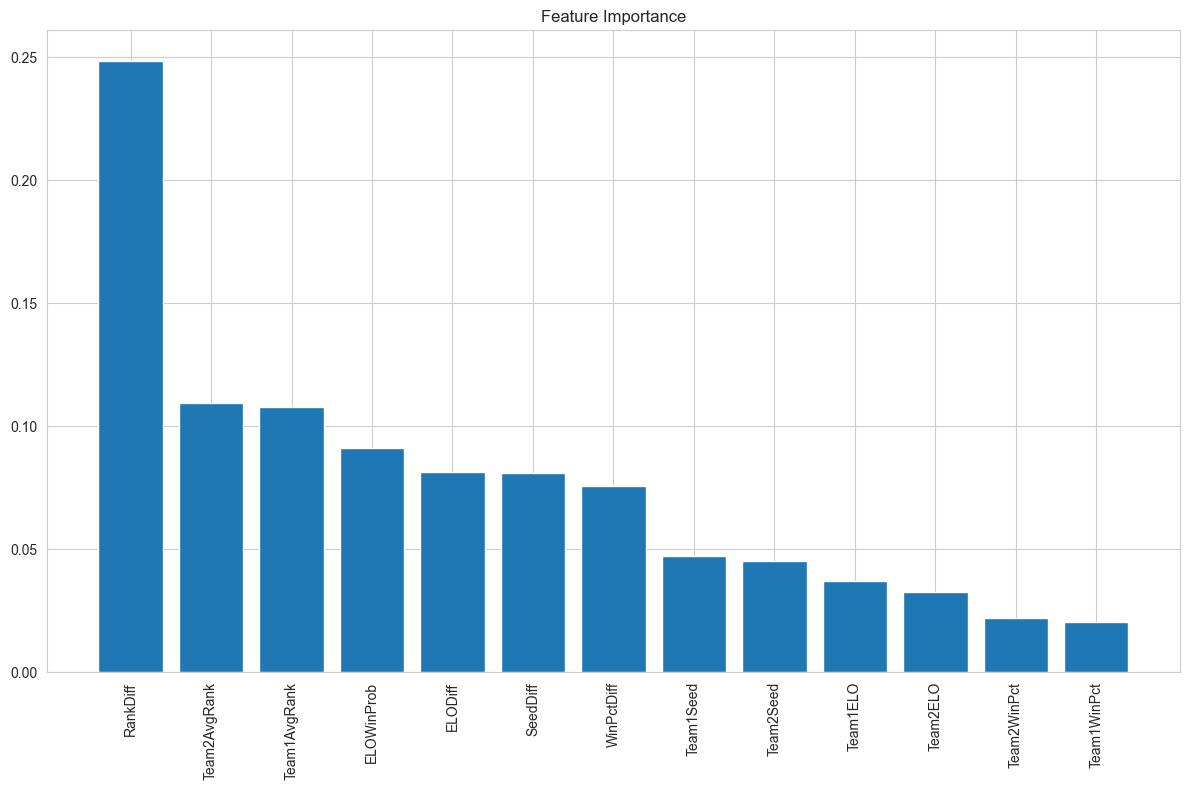

In [44]:
# Initialize the main predictor
predictor = MarchMadnessPredictor(
    data_manager=data_manager,
    current_season=CURRENT_SEASON
)

predictor.initialize_models(train_ml=True)

Creating feature dataset...
Skipping feature creation, we already have a dataframe
      Team1Seed  Team2Seed  SeedDiff  Team1WinPct  Team2WinPct  WinPctDiff  \
0            16         16         0     0.531250     0.566667   -0.035417   
1            16         16         0     0.566667     0.531250   -0.035417   
2             3         14        11     0.774194     0.750000    0.024194   
3            14          3       -11     0.750000     0.774194    0.024194   
4             5         12         7     0.875000     0.812500    0.062500   
...         ...        ...       ...          ...          ...         ...   
1863          4          1        -3     0.656250     0.911765    0.255515   
1864          1         11        10     0.878788     0.611111    0.267677   
1865         11          1       -10     0.611111     0.878788    0.267677   
1866          1          1         0     0.911765     0.878788    0.032977   
1867          1          1         0     0.878788     0.911

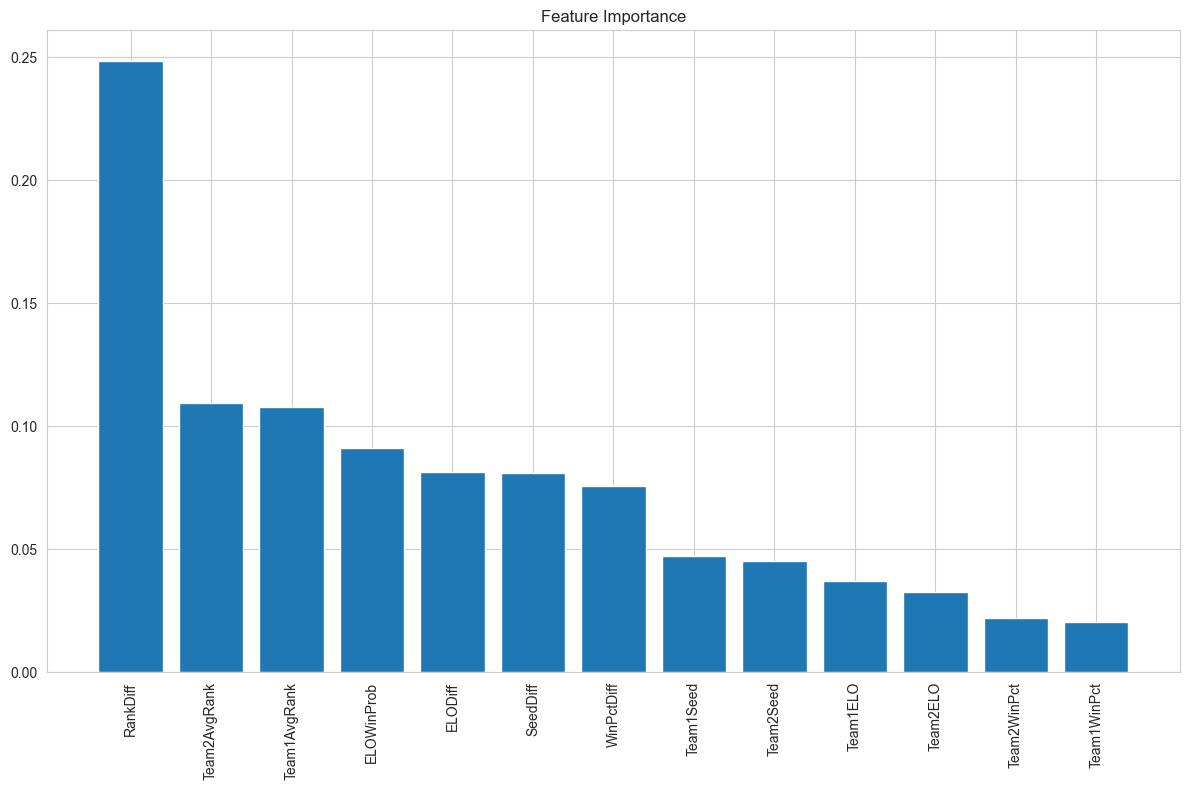

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [50]:
predictor.ml_model.train_model()

In [ ]:
predictor.generate_predictions(get_all_matchups=True)

In [58]:
predictor.ml_model.predict(1222, 1163, 2024)

ValueError: Found array with 0 sample(s) (shape=(0, 13)) while a minimum of 1 is required by RandomForestClassifier.

In [ ]:
print(len(predictor.elo_system.team_elo_ratings.keys()))

248770


In [20]:
print(predictor.data_manager.get_team_name(1104))

Alabama


## 8. Backtest the Predictor

Let's evaluate our prediction models on previous tournaments.

In [30]:
comparison = predictor.compare_methods()

# Extract the best method based on log loss
best_method = comparison.loc[comparison['Log Loss'].idxmin(), 'Method']
print(f"\nBest method based on backtesting: {best_method}")

Backtesting elo predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using elo method...
Brier Score: 0.1758
Accuracy: 0.6866
Log Loss: 0.5257
Backtesting on 2021 tournament using elo method...
Brier Score: 0.2134
Accuracy: 0.6212
Log Loss: 0.6083
Backtesting on 2022 tournament using elo method...
Brier Score: 0.2115
Accuracy: 0.6567
Log Loss: 0.6087
Backtesting on 2023 tournament using elo method...
Brier Score: 0.2266
Accuracy: 0.5970
Log Loss: 0.6492
Backtesting on 2024 tournament using elo method...
Brier Score: 0.1949
Accuracy: 0.6866
Log Loss: 0.5692

Aggregate Results:
Seasons: 5
Average Brier Score: 0.2044
Average Accuracy: 0.6496
Average Log Loss: 0.5922
Backtesting ml predictions on 5 tournament seasons: [2019, 2021, 2022, 2023, 2024]
Backtesting on 2019 tournament using ml method...


ValueError: Found array with dim 3. RandomForestClassifier expected <= 2.

## 9. Generate Tournament Predictions

Now let's generate predictions for the current tournament.

In [ ]:
import os
# Generate predictions using the best method
print(f"Generating predictions for {CURRENT_SEASON} tournament using {best_method} method...")
predictions = predictor.generate_predictions(method=best_method, get_all_matchups=GET_ALL_MATCHUPS)

# Display a sample of the predictions
print(f"\nSample predictions (first 10 rows):")
display(predictions.head(10))

# Save to submission file
predictions[["ID", "Pred"]].to_csv(SUBMISSION_FILE, index=False)
print(f"\nSaved {len(predictions)} predictions to {SUBMISSION_FILE}")

## 10. Visualize the Bracket

Finally, let's generate and visualize the tournament bracket.

In [ ]:
from data_classes.bracket import BracketSimulator
# Initialize the bracket simulator
simulator = BracketSimulator(predictor)

try:
    # Load tournament data into the simulator
    simulator.use_predictor_data()
    
    # Build the bracket structure
    bracket_tree, seed_slot_map = simulator.build_bracket_tree()
    
    # Generate the bracket visualization
    print(f"\nGenerating bracket visualization using {best_method} method...")
    simulator.visualize_bracket(
        method=best_method,
        output_path=f"output/{CURRENT_SEASON}_bracket_{best_method}.png",
        betting_odds=True
    )
    
    print(f"\nSaved bracket visualization to output/{CURRENT_SEASON}_bracket_{best_method}.png")
except Exception as e:
    print(f"Error visualizing bracket: {e}")

## 11. Explore Specific Team Paths

Let's examine the predicted tournament path for some top teams.

In [ ]:
# Get tournament teams
tourney_teams = data_manager.get_tournament_teams(CURRENT_SEASON)

# Merge with team data to get names
tourney_teams = tourney_teams.merge(
    data_manager.data['teams'][['TeamID', 'TeamName']],
    on='TeamID'
)

# Display tournament teams by seed
print("Tournament Teams by Seed:")
display(tourney_teams[['Seed', 'TeamName']].sort_values('Seed'))

# Function to explore a team's path
def explore_team_path(team_name):
    # Find the team ID
    team_row = tourney_teams[tourney_teams['TeamName'] == team_name]
    
    if len(team_row) == 0:
        print(f"Team '{team_name}' not found in the tournament")
        return
    
    team_id = team_row.iloc[0]['TeamID']
    team_seed = team_row.iloc[0]['Seed']
    
    print(f"\nExploring tournament path for {team_seed} {team_name} (ID: {team_id})")
    
    try:
        # Get the team's tournament path
        path = simulator.get_team_path(team_id)
        
        # Create a DataFrame for the path
        path_df = pd.DataFrame([
            {
                "Round": p["round"],
                "Opponent": p["opponent_name"],
                "Opponent Seed": p["opponent_seed"],
                "Win Probability": f"{p['win_probability']:.1%}"
            }
            for p in path
        ])
        
        display(path_df)
        
        # Calculate championship probability
        champ_prob = np.prod([p["win_probability"] for p in path])
        print(f"Championship probability: {champ_prob:.2%}")
        
    except Exception as e:
        print(f"Error getting team path: {e}")

# Explore paths for top 5 teams (adjust as needed)
top_teams = current_stats.sort_values('NetEff', ascending=False).head(5)['TeamName'].values

for team in top_teams:
    explore_team_path(team)

## 12. Summary and Conclusion

Let's summarize our March Madness prediction workflow:

In [ ]:
print("March Madness Prediction Workflow Summary")
print("===========================================\n")

print(f"Data loaded from: {DATA_DIR}")
print(f"Gender: {'Men\'s' if GENDER == 'M' else 'Women\'s'} Tournament")
print(f"Target season: {CURRENT_SEASON}")
print(f"ELO history: {ELO_START_YEAR}-{CURRENT_SEASON} ({CURRENT_SEASON-ELO_START_YEAR+1} seasons)")
print(f"ML training history: {ML_START_YEAR}-{CURRENT_SEASON} ({CURRENT_SEASON-ML_START_YEAR+1} seasons)")

print(f"\nBest prediction method based on backtesting: {best_method}")
if 'aggregate' in results:
    print(f"Backtest accuracy: {results['aggregate']['accuracy']:.4f}")
    print(f"Backtest log loss: {results['aggregate']['log_loss']:.4f}")

print(f"\nSubmission file created: {SUBMISSION_FILE}")
print(f"Number of predictions: {len(predictions)}")

print(f"\nBracket visualization saved to: output/{CURRENT_SEASON}_bracket_{best_method}.png")

print("\nTournament favorites:")
for i, (_, team) in enumerate(current_stats.head(5).iterrows()):
    print(f"  {i+1}. {team['TeamName']} - Net Efficiency: {team['NetEff']:.1f}")